# From Grains to Pores — Notebook 02b

**MOOC "The Hydrology of Soil" — bridging Chapter 1 and Chapter 2**

---

Chapter 1 described soil through its **grain-size distribution** — the
"percentage finer" curve. Chapter 2 built the **retention curve** from a
**pore-size distribution**. These are two different things: Chapter 1 measures
the *solid grains*, Chapter 2 needs the *empty pores between them*.

This notebook builds the bridge — and it is important to say at the outset
that **the bridge is a heuristic, not a law of physics**:

> There is **no exact relationship** between grain size and pore size.
> Packing, sorting, aggregation, and structure all intervene. Chapter 1's own
> slide says it plainly — *"smaller grains don't always mean smaller pores"*,
> *"the relationship between grain size and pore size is not direct"*.

So why do it at all? Because a *rough* grain→pore rule is genuinely useful: it
lets a measured granulometric curve produce a first-guess retention curve. The
goal of this notebook is to let students **use** that bridge and, at the same
time, **see exactly where it breaks** — which is the more valuable lesson.

What the notebook does:

1. re-uses the **Chapter 1** grain-size curve (the same lognormal model and
   functions);
2. applies a **heuristic grain → pore-radius rule** to obtain a pore-size
   distribution;
3. feeds that distribution into the **Chapter 2** "fill smallest first" /
   Young–Laplace construction to get a retention curve;
4. compares the heuristic prediction with a measured-style van Genuchten
   curve, so the **error of the bridge** is visible.

Run the cells in order (Shift+Enter). Plain NumPy/SciPy.


## 0 — Setup

In [1]:
try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *

print("Setup complete")

  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-ggrpt3xg
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-ggrpt3xg
  Resolved https://github.com/panzerotto/soil_course.git to commit b7300f39fe32db4ac152dc54001847411aca5969
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=13527 sha256=682bfee21335865cb24b13dd61912621ced406f8520dde09a0b7489f88e23480
  Stored in directory: /tmp/pip-ephem-wheel-cache-l432z7_0/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


## 1 — The Chapter 1 grain-size curve (re-used)

These are the **same functions as the Chapter 1 notebook**
(`Soil_Texture_Structure.ipynb`). The grain-size distribution is modelled as a
**lognormal in grain diameter**: a curve of "percentage finer" `N(d)` set by

* `d50` — the median grain diameter (mm);
* `sigma` — the log-spread (small = uniform/poorly-graded, large = well-graded).

We reproduce them here so this notebook is self-contained; if you have run the
Chapter 1 notebook, these are identical and could be imported instead.


In [2]:
# Chapter 1 grain-size curve check
print_grain_curve_check(d50=0.2, sigma=0.6)

grain curve, d50 = 0.2 mm, sigma = 0.6:
  D10 = 0.0927 mm
  D50 = 0.2000 mm
  D90 = 0.4315 mm


## 2 — The bridge: a heuristic grain → pore rule

Here is the **improper connection**, stated honestly.

For an idealised packing of uniform spheres of diameter $d$, geometry gives a
characteristic pore (throat) radius that is a *fixed fraction* of the grain
diameter. Different idealisations give different fractions; a widely used
rough value is

$$r_{\text{pore}} \;\approx\; \beta \, d,\qquad \beta \sim 0.2,$$

i.e. **the pore radius is a few tenths of the grain diameter**. The constant
$\beta$ (call it the *pore ratio*) is where all the uncertainty lives:

* loose packing of well-rounded grains → larger $\beta$;
* dense packing, angular grains → smaller $\beta$;
* **aggregated clay** → the rule fails outright, because clay platelets build
  *large* inter-aggregate pores from *tiny* grains ($\beta$ effectively huge).

Two more honest caveats are built into the rule below:

* a **whole distribution** of grains maps to a **whole distribution** of
  pores — we map the lognormal grain curve to a lognormal pore curve, keeping
  the spread but optionally letting packing change it;
* we therefore expose a second knob, a **spread factor**, so students can see
  that the pore distribution need not have the same width as the grain
  distribution.


In [3]:
# Heuristic grain -> pore example
print_grains_to_pores_example(d50_mm=0.2, sigma_grain=0.6, beta=0.2)

grain curve  d50 = 0.20 mm, sigma = 0.6
  -> heuristic pore distribution:
     median pore radius = 40.00 micrometres
     pore log-spread    = 0.60


## 3 — The Chapter 2 machinery (re-used)

These are the **Chapter 2** functions (`Ch2_Energy_of_Soil_Water.ipynb`):
the lognormal **pore-size distribution**, the **Young–Laplace** relation, and
the **"fill smallest first"** construction of the retention curve. Reproduced
here so the notebook is self-contained.


In [4]:
# Chapter 2 pore and retention functions are now loaded from the package.
# You can test the Young-Laplace relation with:
young_laplace_head(20e-6)

np.float64(0.7420998980632008)

## 4 — The whole chain, in one figure

Now the connection. The function below takes a **Chapter 1 grain-size curve**,
runs it through the **heuristic bridge**, and produces the **Chapter 2
retention curve** — and draws all three panels so the path is visible:

**grain-size curve  →  pore-size distribution  →  retention curve.**


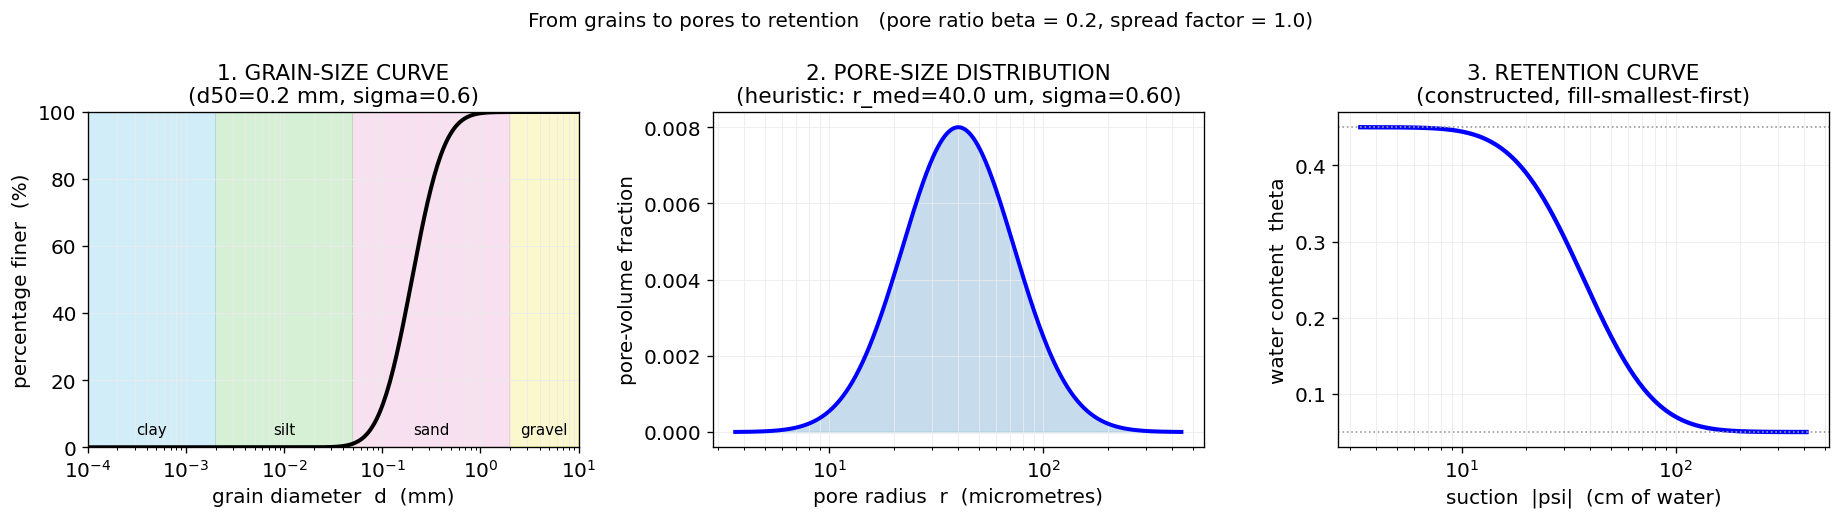

(40.0, 0.6)

In [5]:
# Full chain: grain-size curve -> pore distribution -> retention curve
grains_to_retention(d50_mm=0.2, sigma_grain=0.6, beta=0.2)

Read the three panels left to right: a granulometric curve measured in
the lab (Chapter 1) becomes, *via the heuristic*, a pore-size distribution, and
that becomes a retention curve (Chapter 2). The whole of Chapters 1 and 2 is
chained into a single pipeline.


## 5 — Interactive: turn the knobs of the bridge

The two grain-curve knobs (`d50`, `sigma_grain`) are **Chapter 1** quantities —
they describe a real, measurable soil. The two bridge knobs are the
**heuristic**:

* **`beta`** — the pore ratio. This is the single most uncertain number in the
  whole notebook. Slide it and watch the retention curve shift bodily along the
  suction axis.
* **`spread_factor`** — how much packing widens (>1) or narrows (<1) the pore
  distribution relative to the grain distribution.

The lesson to take away: the grain curve is *data*; `beta` and
`spread_factor` are *assumptions*, and the retention curve depends on the
assumptions at least as much as on the data.

> Without `ipywidgets`, call `grains_to_retention(...)` directly.


In [6]:
# Interactive version
interactive_grains_to_retention()

interactive(children=(FloatLogSlider(value=0.2, continuous_update=False, description='d50 (mm)', max=1.0, min=…

interactive(children=(FloatLogSlider(value=0.2, continuous_update=False, description='d50 (mm)', max=1.0, min=…

## 6 — How wrong is the bridge? Compare with a measured curve

The honest test. We take the retention curve **predicted from the grain curve**
through the heuristic, and overlay a **van Genuchten curve** standing in for a
*measured* retention curve. The gap between them is the **error of the
bridge** — and it is generally not small.


In [ ]:
# Compare the heuristic curve with a van Genuchten "measured" curve
bridge_vs_measured(
    d50_mm=0.2,
    sigma_grain=0.6,
    beta=0.2,
    alpha_meas=0.04,
    n_meas=2.0
)

In [ ]:
# Interactive comparison
interactive_bridge_vs_measured()

## Exercises

1. **Tune the bridge.** In Section 6, fix the grain curve (`d50`,
   `sigma_grain`) and try to make the heuristic curve match the "measured"
   van Genuchten curve by adjusting **only `beta`**. Can you get a good match?
   What value of `beta` did it take?

2. **Where the bridge fails — clay.** Set `d50 = 0.001 mm` (a clay-sized
   soil). The heuristic predicts extremely small pores and a retention curve
   shifted to enormous suction. Using Chapter 1's slide on *bimodal pore
   structure*, explain why a real aggregated clay holds a lot of water in
   **large** inter-aggregate pores that the rule `r ~ beta·d` completely
   misses.

3. **Data vs assumption.** In Section 5, change the grain curve `d50` by a
   factor of 2, then instead change `beta` by a factor of 2. Compare the two
   resulting retention curves. Does the prediction move more when you change
   the *data* or the *assumption*?

4. **Sorting carries through.** A poorly-graded (uniform) sand has a small
   `sigma_grain`. Follow it through the three panels of Section 4. Does the
   *steepness* of the retention curve reflect the *uniformity* of the grains?
   Why should it?

5. **Is the connection legitimate?** Write two or three sentences for a fellow
   student explaining in what sense the grain-size → pore-size link is
   "improper", and in what sense it is still worth doing. (There is no single
   right answer — this is the point of the notebook.)

---

*Companion to the MOOC "The Hydrology of Soil", Notebook 02b — the heuristic
bridge from Chapter 1 (grain size) to Chapter 2 (pore size and retention).
The grain -> pore mapping is a deliberately simple heuristic and is not a
physical law. Licensed CC BY-SA, consistent with the lecture slides.*
